# 02 – Pipeline Sentinel-2 (escenario real)

**Objetivo:** Reproducir el pipeline de la tesis con datos reales de Sentinel-2, usando como entrada un polígono (simulado) y siguiendo el flujo:

1. **Descarga de Sentinel-2** (bandas B4, B8, etc.) para el polígono de interés.
2. **Preprocesamiento**: recorte, cálculo de NDVI y otras máscaras.
3. **Segmentación**: filtro convolucional + U-Net ligera (aplicado ahora a datos reales).
4. **Visualización**: mapa “verde/amarillo/rojo” de salud del cultivo.
5. **Resultados**: listos para integrarse al backend.

> Este notebook es la transición del “laboratorio controlado” (notebook 01) hacia un escenario real, preparando el terreno para la versión de producción.

In [1]:
# Librerías esenciales
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, mapping

import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Polígono de la parcela nueva (coordenadas en WGS84)
# NOTE: GeoJSON / CRS84 expects [longitude, latitude] (lon, lat).
# Los datos originales están en [lat, lon], por eso invertimos el orden aquí.
polygon_coords = [
    [
        [-67.477732,8.890243],
        [-67.472585,8.891811],
        [-67.482623,8.921237],
        [-67.487942,8.916531],
        [-67.479534,8.892108],
        [-67.47859,8.892151]
    ]
]

parcela = {
    "type": "Feature",
    "properties": {"name": "Parcela (nueva)"},
    "geometry": {
        "type": "Polygon",
        "coordinates": polygon_coords
    }
}

parcela

{'type': 'Feature',
 'properties': {'name': 'Parcela (nueva)'},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-67.477732, 8.890243],
    [-67.472585, 8.891811],
    [-67.482623, 8.921237],
    [-67.487942, 8.916531],
    [-67.479534, 8.892108],
    [-67.47859, 8.892151]]]}}

In [3]:
if polygon_coords[0][0] != polygon_coords[0][-1]:
    polygon_coords[0].append(polygon_coords[0][0])

In [4]:
# Debug: inspect the GeoJSON geometry structure
print('polygon_coords (len):', len(polygon_coords))
print('polygon_coords[0] type:', type(polygon_coords[0]), 'len:', len(polygon_coords[0]))
print('first coordinate:', polygon_coords[0][0])
print('full geometry coordinates:', parcela['geometry']['coordinates'])


polygon_coords (len): 1
polygon_coords[0] type: <class 'list'> len: 7
first coordinate: [-67.477732, 8.890243]
full geometry coordinates: [[[-67.477732, 8.890243], [-67.472585, 8.891811], [-67.482623, 8.921237], [-67.487942, 8.916531], [-67.479534, 8.892108], [-67.47859, 8.892151], [-67.477732, 8.890243]]]


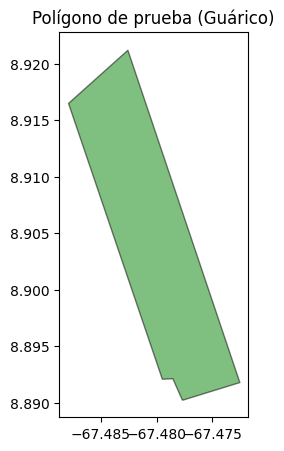

In [5]:
gdf = gpd.GeoDataFrame.from_features([parcela])
gdf.crs = "EPSG:4326"
gdf.plot(figsize=(5,5), color='green', alpha=0.5, edgecolor='black')
plt.title("Polígono de prueba (Guárico)")
plt.show()

In [6]:
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
import os

# credenciales deben venir de variables de entorno para evitar exposición
client_id = os.environ.get("SENTINEL_CLIENT_ID")
client_secret = os.environ.get("SENTINEL_CLIENT_SECRET")

if client_id is None or client_secret is None:
    raise ValueError("Set environment variables SENTINEL_CLIENT_ID and SENTINEL_CLIENT_SECRET before running")

client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)

token = oauth.fetch_token(
    token_url="https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
    client_id=client_id,
    client_secret=client_secret,
    include_client_id=True
)

print("Token OK:", token["access_token"][0:40], "…")

Token OK: eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwi …


In [25]:
import json

evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04"],
    output: {
      bands: 3,
      // For PNG output, request UINT8 so the service returns 0-255 values.
      sampleType: "UINT8",
    },
  }
}

function evaluatePixel(sample) {
  // Sentinel reflectance is usually in [0, 0.3].
  // Scale to 0-255 for a visible true-color image.
  // Clamp to avoid overflow.
  const r = Math.min(255, Math.max(0, 255 * sample.B04));
  const g = Math.min(255, Math.max(0, 255 * sample.B03));
  const b = Math.min(255, Math.max(0, 255 * sample.B02));
  return [r, g, b];
}
"""

request = {
    "input": {
        "bounds": {
            "geometry": parcela["geometry"],
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
        },
        "data": [{
            "type": "sentinel-2-l2a",
            "dataFilter": {
                "timeRange": {
                    "from": "2026-01-21T00:00:00Z",
                    "to": "2026-01-21T23:59:59Z"
                },
                "maxCloudCoverage": 20
            }
        }]
    },
    "output": {"width": 512, "height": 512},
    "evalscript": evalscript,
}

response = oauth.post("https://sh.dataspace.copernicus.eu/api/v1/process", json=request)
try:
    response.raise_for_status()
except Exception as e:
    print("HTTP", response.status_code)
    print(response.text)
    raise

with open("parcel_true_color.png", "wb") as f:
    f.write(response.content)

print("Imagen guardada: parcel_true_color.png")


Imagen guardada: parcel_true_color.png


parcel_true_color.png -> shape (512, 512, 3) dtype uint8 min 0 max 64
  channel 0: min=0, max=64
  channel 1: min=0, max=47
  channel 2: min=0, max=39


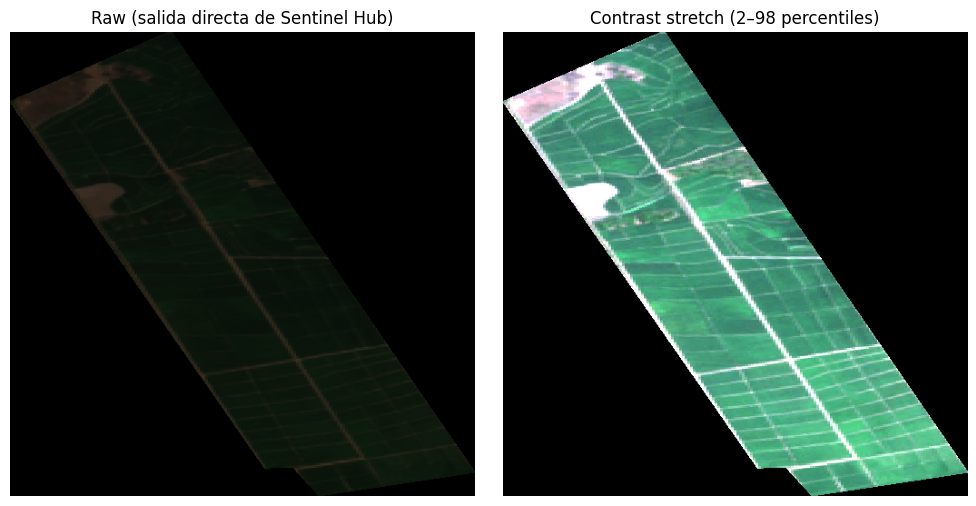

In [8]:
# Diagnóstico: ¿por qué la imagen PNG se ve muy oscura?
# Sentinel-2 reflectancia suele ser baja (<= 0.3), por lo que al mapear directamente
# a 0-255 la imagen puede quedar muy oscura. Aquí hacemos un estiramiento de contraste
# (clipping entre percentiles 2-98) para que sea más visible.
from PIL import Image
import numpy as np

img = Image.open("parcel_true_color.png")
arr = np.array(img)
print("parcel_true_color.png -> shape", arr.shape, "dtype", arr.dtype, "min", arr.min(), "max", arr.max())
if arr.ndim == 3:
    for c in range(arr.shape[2]):
        print(f"  channel {c}: min={arr[...,c].min()}, max={arr[...,c].max()}")

# Stretch (2%-98%) por canal
arr_float = arr.astype(np.float32)
clipped = np.zeros_like(arr_float)

for c in range(arr.shape[2]):
    p2, p98 = np.percentile(arr_float[..., c], (2, 98))
    span = p98 - p2
    if span <= 0:
        # canal homogéneo (posiblemente todo 0) -> no cambiar, deja 0
        clipped[..., c] = np.clip(arr_float[..., c] / 255.0, 0, 1)
    else:
        clipped[..., c] = np.clip((arr_float[..., c] - p2) / span, 0, 1)

stretched = np.nan_to_num(clipped)  # elimina nan en caso de datos raros
stretched = (stretched * 255).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Raw (salida directa de Sentinel Hub)")
plt.imshow(arr)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Contrast stretch (2–98 percentiles)")
plt.imshow(stretched)
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
evalscript_ndvi = """
//VERSION=3
function setup() {
  return {
    input: ["B04", "B08"],
    output: {
      bands: 1,
      // AUTO lets the service choose a sample type compatible with
      // the requested format (TIFF supports FLOAT32, PNG supports UINT8).
      sampleType: "AUTO",
    },
  }
}
function evaluatePixel(sample) {
  let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
  return [ndvi];
}
"""

# 3) Petición de procesamiento
request_ndvi = {
    "input": {
        "bounds": {
            "geometry": parcela["geometry"],
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
        },
        "data": [{
            "type": "sentinel-2-l2a",
            "dataFilter": {
                "timeRange": {
                    "from": "2026-01-21T00:00:00Z",
                    "to": "2026-01-21T23:59:59Z"
                },
                "maxCloudCoverage": 20
            }
        }]
    },
    "output": {
        "width": 512,
        "height": 512,
        # enviamos TIFF, no es necesario sampleType aquí
        "format": {"type": "image/tiff"}
    },
    "evalscript": evalscript_ndvi,
}

# 4) Llamada al endpoint de Sentinel Hub
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

# Construimos explícitamente el header con el access token
headers = {
    "Authorization": f"Bearer {token['access_token']}",
    "Content-Type": "application/json"
}

# Hacemos la petición de NDVI (ahora debería ir bien)
resp_ndvi = requests.post(PROCESS_URL, json=request_ndvi, headers=headers)
try:
    resp_ndvi.raise_for_status()
except Exception as e:
    print("Error:", resp_ndvi.status_code, resp_ndvi.text)
    raise

# Guardamos el GeoTIFF resultante
with open("parcel_ndvi.tiff", "wb") as f:
    f.write(resp_ndvi.content)

print("NDVI guardado como: parcel_ndvi.tiff")


NDVI guardado como: parcel_ndvi.tiff


Cargar el GeoTIFF generado por Sentinel Hub (NDVI real) y visualizar su distribución. Después, convertirlo en una máscara binaria usando el umbral NDVI > 0.3 para identificar las áreas verdes del cultivo.

/Users/jhonattan_escorihuela/Documents/precision-agriculture/backend/core/venv_39/lib/python3.9/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


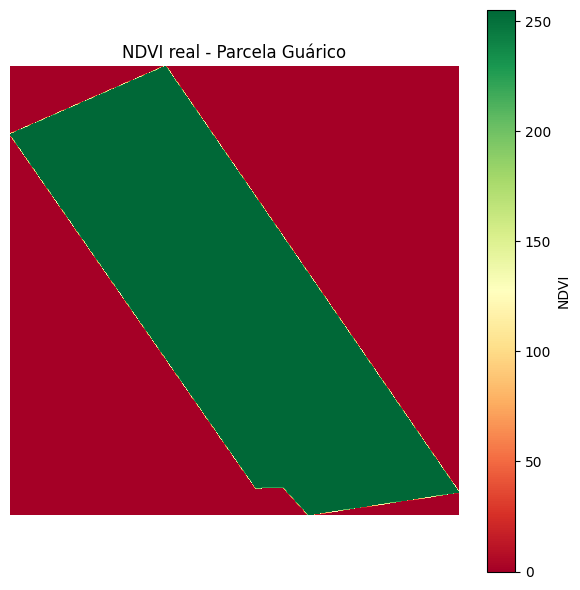

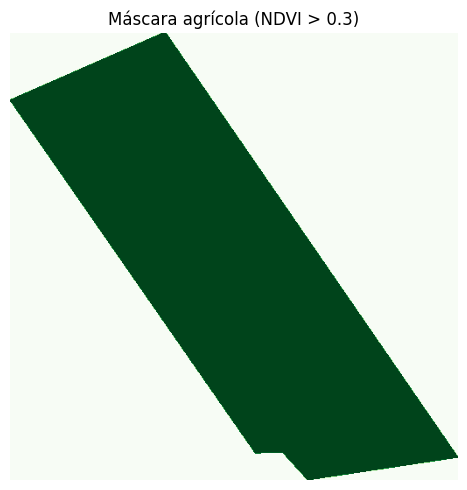

In [18]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1) Cargar el NDVI real desde el GeoTIFF
with rasterio.open("parcel_ndvi.tiff") as src:
    ndvi = src.read(1)
    ndvi_profile = src.profile

# 2) Visualizar el NDVI
plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI real - Parcela Guárico")
plt.axis("off")
plt.tight_layout()
plt.show()

# 3) Construir máscara NDVI > 0.3
mask_ndvi = ndvi > 0.3

plt.figure(figsize=(5,5))
plt.imshow(mask_ndvi, cmap="Greens")
plt.title("Máscara agrícola (NDVI > 0.3)")
plt.axis("off")
plt.tight_layout()
plt.show()

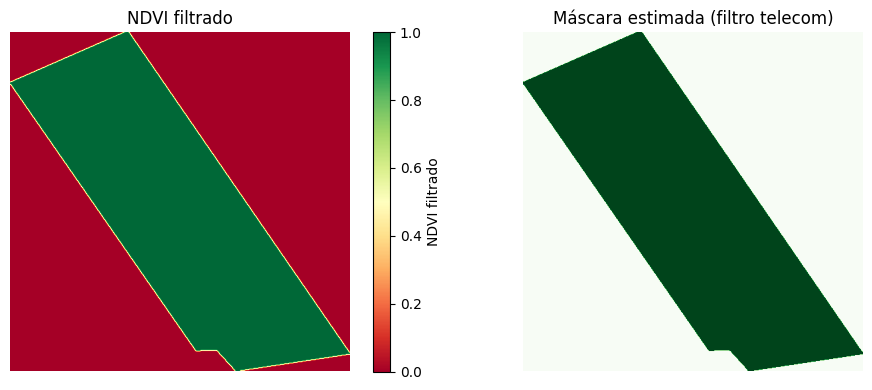

In [19]:
from scipy.signal import convolve2d

# Kernel tipo gauss / media
kernel = np.array([
    [0.0625, 0.125, 0.0625],
    [0.125,  0.25,  0.125],
    [0.0625, 0.125, 0.0625]
])

# Normalizar NDVI a [0,1]
ndvi_norm = (ndvi - np.nanmin(ndvi)) / (np.nanmax(ndvi) - np.nanmin(ndvi))

# Aplicamos la convolución
filtered = convolve2d(ndvi_norm, kernel, mode="same", boundary="symm")

# Convertimos a máscara con umbral 0.35
mask_filtered = filtered > 0.35

# Visualizamos el resultado
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("NDVI filtrado")
plt.imshow(filtered, cmap="RdYlGn")
plt.colorbar(label="NDVI filtrado")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Máscara estimada (filtro telecom)")
plt.imshow(mask_filtered, cmap="Greens")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import jaccard_score, f1_score

# Aplanar las máscaras
truth = mask_ndvi.flatten().astype(int)
predicted = mask_filtered.flatten().astype(int)

# Calcular IoU y Dice
iou_score = jaccard_score(truth, predicted)
dice_score = f1_score(truth, predicted)

print(f"IoU (filtro):  {iou_score:.4f}")
print(f"Dice (filtro): {dice_score:.4f}")

IoU (filtro):  0.9964
Dice (filtro): 0.9982


## Segmentación con U‑Net ligera sobre NDVI real

En esta etapa se entrena una red convolucional tipo U‑Net mínima,
usando como entrada el NDVI real recortado de Sentinel‑2 y como
referencia una máscara agrícola basada en NDVI > 0.3.

El objetivo es comparar el desempeño del modelo de IA frente al
método clásico de filtrado convolucional (enfoque telecom).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
IoU (U‑Net):  0.9857
Dice (U‑Net): 0.9928


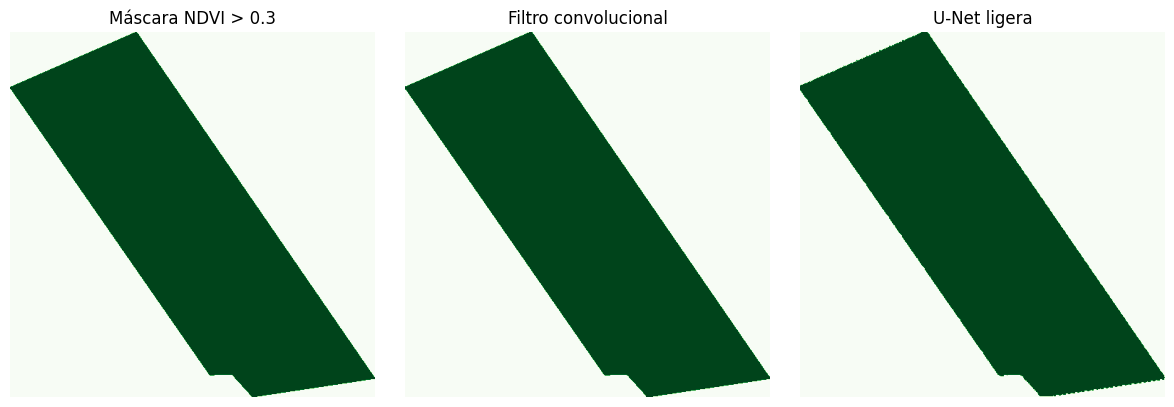

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import jaccard_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1) Preparar datos
# -------------------------------

# Normalizamos NDVI real
ndvi_real = ndvi.copy()
ndvi_real = (ndvi_real - np.nanmin(ndvi_real)) / (np.nanmax(ndvi_real) - np.nanmin(ndvi_real))

# Input y target
X = ndvi_real.reshape(1, ndvi_real.shape[0], ndvi_real.shape[1], 1).astype("float32")
Y = mask_ndvi.reshape(1, mask_ndvi.shape[0], mask_ndvi.shape[1], 1).astype("float32")

# -------------------------------
# 2) Definir U‑Net ligera
# -------------------------------

def build_unet(input_shape):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(8, 3, activation="relu", padding="same")(inputs)
    p1 = layers.MaxPooling2D()(c1)

    # Bottleneck
    c2 = layers.Conv2D(16, 3, activation="relu", padding="same")(p1)

    # Decoder
    u1 = layers.UpSampling2D()(c2)
    m1 = layers.Concatenate()([u1, c1])
    c3 = layers.Conv2D(8, 3, activation="relu", padding="same")(m1)

    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c3)

    return models.Model(inputs, outputs)

model = build_unet(X.shape[1:])
model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# -------------------------------
# 3) Entrenamiento
# -------------------------------

history = model.fit(
    X, Y,
    epochs=15,
    verbose=0
)

# -------------------------------
# 4) Predicción
# -------------------------------

pred = model.predict(X)[0, :, :, 0]
mask_unet = pred > 0.5

# -------------------------------
# 5) Métricas
# -------------------------------

truth = mask_ndvi.flatten().astype(int)
predicted = mask_unet.flatten().astype(int)

iou_unet = jaccard_score(truth, predicted)
dice_unet = f1_score(truth, predicted)

print(f"IoU (U‑Net):  {iou_unet:.4f}")
print(f"Dice (U‑Net): {dice_unet:.4f}")

# -------------------------------
# 6) Visualización
# -------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Máscara NDVI > 0.3")
plt.imshow(mask_ndvi, cmap="Greens")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Filtro convolucional")
plt.imshow(mask_filtered, cmap="Greens")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("U‑Net ligera")
plt.imshow(mask_unet, cmap="Greens")
plt.axis("off")

plt.tight_layout()
plt.show()

## Clasificación de salud del cultivo (NDVI + textura)

En esta etapa se clasifica la salud del cultivo únicamente en las zonas
donde previamente se detectó vegetación, combinando:

- NDVI (información espectral)
- Respuesta del filtro convolucional (textura / vecindad)

Esto permite detectar zonas con estrés localizado que no se observan
usando NDVI puntual únicamente.

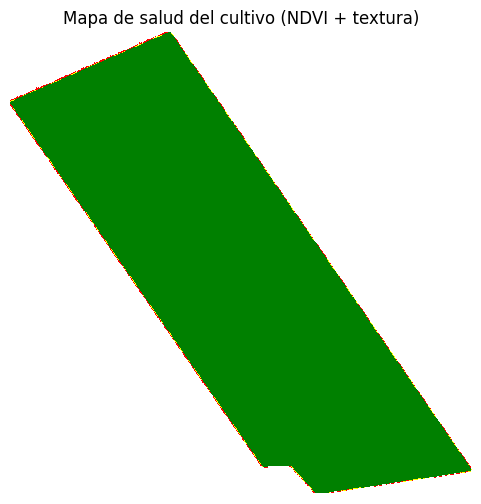

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# 1) Definir umbrales de salud
# -----------------------------------

# NDVI
NDVI_SANO = 0.6
NDVI_ALERTA = 0.45

# Textura (respuesta del filtro)
TEXTURA_BAJA = 0.40
TEXTURA_MEDIA = 0.55

# -----------------------------------
# 2) Inicializar mapa de salud
# -----------------------------------
# 0 = no cultivo
# 1 = crítico (rojo)
# 2 = alerta (amarillo)
# 3 = sano (verde)

health_map = np.zeros_like(ndvi, dtype=np.uint8)

# -----------------------------------
# 3) Clasificación combinada
# -----------------------------------

for i in range(ndvi.shape[0]):
    for j in range(ndvi.shape[1]):
        if mask_unet[i, j]:  # solo donde hay cultivo
            if ndvi[i, j] > NDVI_SANO and filtered[i, j] > TEXTURA_MEDIA:
                health_map[i, j] = 3  # sano
            elif ndvi[i, j] > NDVI_ALERTA and filtered[i, j] > TEXTURA_BAJA:
                health_map[i, j] = 2  # alerta
            else:
                health_map[i, j] = 1  # crítico

# -----------------------------------
# 4) Visualización final
# -----------------------------------

from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "white",   # 0 - no cultivo
    "red",     # 1 - crítico
    "yellow",  # 2 - alerta
    "green"    # 3 - sano
])

plt.figure(figsize=(6,6))
plt.imshow(health_map, cmap=cmap)
plt.title("Mapa de salud del cultivo (NDVI + textura)")
plt.axis("off")
plt.show()

## Construcción del dataset para clasificación de salud (IA)

En esta etapa se construye el conjunto de datos que alimentará
el modelo de inteligencia artificial.  
Cada muestra corresponde a un píxel del cultivo e incluye:

- NDVI (información espectral)
- Respuesta del filtro convolucional (textura)
- Clase de salud asignada por el método clásico

Este dataset permitirá entrenar un modelo supervisado que aprenda
a clasificar la salud del cultivo sin depender de umbrales fijos.

In [15]:
import pandas as pd
import numpy as np

# ----------------------------------
# 1) Inicializar listas de datos
# ----------------------------------
features = []
labels = []

# ----------------------------------
# 2) Construcción del dataset
# ----------------------------------

for i in range(ndvi.shape[0]):
    for j in range(ndvi.shape[1]):

        if mask_unet[i, j]:  # solo donde hay cultivo

            ndvi_val = ndvi_norm[i, j]
            texture_val = filtered[i, j]

            # Clase de salud (la que ya definimos)
            health_class = health_map[i, j]

            features.append([ndvi_val, texture_val])
            labels.append(health_class)

# ----------------------------------
# 3) DataFrame final
# ----------------------------------

df_ai = pd.DataFrame(
    features,
    columns=["NDVI", "Texture"]
)

df_ai["Health_Class"] = labels

df_ai.head()

,NDVI,Texture,Health_Class
0,0.0,0.0,1
1,0.0,0.0,1
2,0.0,0.0,1
3,0.0,0.0,1
4,0.0,0.0,1


In [16]:
print(np.nanmin(ndvi_norm), np.nanmax(ndvi_norm))

0.0 1.0
